# Exercise 1

Create a model using K-Nearest Neigbors to perform classification using the personality dataset.

0 -'introvert'

1 - 'extrovert'

## A. Import libraries

In [61]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

data = {
    "name": [
        "Mich",
        "Ella",
        "Kevin",
        "Recio",
        "Mark"
    ],
    "Time_spent_Alone": [
        3,
        2,
        1,
        8,
        5
    ],
    "Stage_fear": [
        1,
        0,
        0,
        0,
        1
    ],
    "Social_event_attendance": [
        6,
        8,
        9,
        0,
        3
    ],
    "Going_outside": [
        7,
        6,
        4,
        0,
        0
    ],
    "Drained_after_socializing": [
        0,
        0,
        0,
        1,
        0
    ],
    "Friends_circle_size": [
        14,
        7,
        9,
        9,
        2
    ],
    "Post_frequency": [
        5,
        8,
        3,
        3,
        6
    ],
    "Personality": [
        1,
        1,
        1,
        0,
        0
    ]
}

df = pd.DataFrame(data)

## B. Load and understand the dataset

Display the first 5 rows of the dataset using `.head()`

In [62]:
print(df.head())

    name  Time_spent_Alone  Stage_fear  Social_event_attendance  \
0   Mich                 3           1                        6   
1   Ella                 2           0                        8   
2  Kevin                 1           0                        9   
3  Recio                 8           0                        0   
4   Mark                 5           1                        3   

   Going_outside  Drained_after_socializing  Friends_circle_size  \
0              7                          0                   14   
1              6                          0                    7   
2              4                          0                    9   
3              0                          1                    9   
4              0                          0                    2   

   Post_frequency  Personality  
0               5            1  
1               8            1  
2               3            1  
3               3            0  
4               6      

Display the summary of all the features of the dataset using `.info()`

In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   name                       5 non-null      object
 1   Time_spent_Alone           5 non-null      int64 
 2   Stage_fear                 5 non-null      int64 
 3   Social_event_attendance    5 non-null      int64 
 4   Going_outside              5 non-null      int64 
 5   Drained_after_socializing  5 non-null      int64 
 6   Friends_circle_size        5 non-null      int64 
 7   Post_frequency             5 non-null      int64 
 8   Personality                5 non-null      int64 
dtypes: int64(8), object(1)
memory usage: 492.0+ bytes


Display the total number of samples from each label using `.value_counts()`

In [64]:
print(df["Personality"].value_counts())

Personality
1    3
0    2
Name: count, dtype: int64


Use a histogram to display the number of followers for each samples
 - The x axis should be the number of followers/friends
 - The y axis should be the number of samples in the dataset

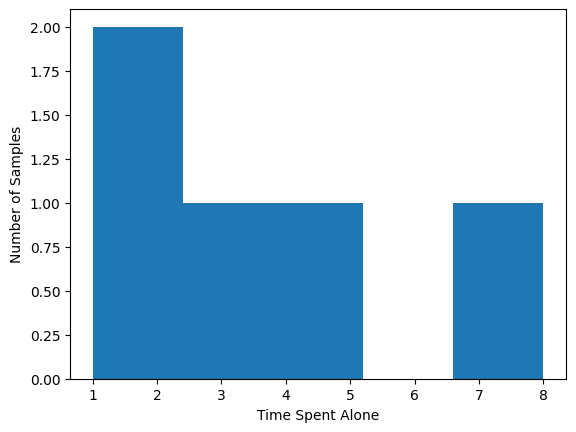

In [65]:
plt.hist(df["Time_spent_Alone"], bins=5)
plt.xlabel("Time Spent Alone")
plt.ylabel("Number of Samples")
plt.show()

Remove the name column using `drop()` method

In [66]:
df = df.drop("name", axis=1)

## C. Split the dataset into training and test set

Convert the features into an numpy array using `.values()` and store it in a variable "X"

In [67]:
X = df.drop("Personality", axis=1).values

Convert the labels into an numpy array using `.values()` and store it in a variable "y"

In [68]:
y = df["Personality"].values

Use `train_test_split()` to split the data.

- Declare a variable `X_train` that will hold the training data
- Declare a variable `X_test` that will hold the test data
- Declare a variable `y_train` that will hold the label of the training data
- Declare a variable `y_test` that will hold the label of the test data


In [69]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Display the dimensions of each variables using `.shape()`

In [70]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(4, 7)
(1, 7)
(4,)
(1,)


## D. Create the model

Use KNN as a classifier by using `KNeighborsClassifier()`

In [71]:
model = KNeighborsClassifier(n_neighbors=1)

Train the model using the `.fit()`

In [72]:
model.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=1)

Test the model using the `.predict()`

In [73]:
y_pred = model.predict(X_test)

## E. Evaluate the model

Create a confusion matrix

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


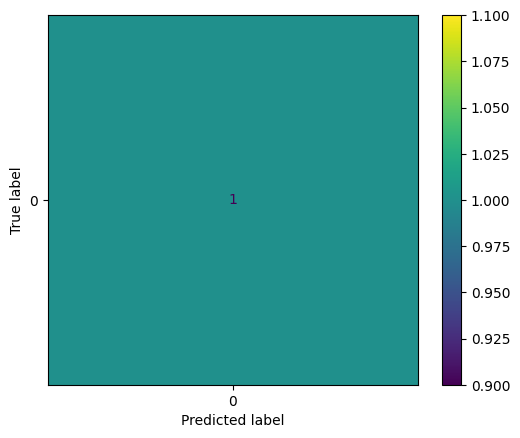

In [74]:
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot()

plt.show()

Display the accuracy

In [75]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 1.0


Display the precision

In [76]:
print("Precision:", precision_score(y_test, y_pred, zero_division=0))

Precision: 1.0


Display the recall

In [77]:
print("Recall:", recall_score(y_test, y_pred, zero_division=0))

Recall: 1.0


Display the f1-score

In [78]:
print("F1 Score:", f1_score(y_test, y_pred, zero_division=0))

F1 Score: 1.0


## F. Predict your own personality

Enter your own features and use the model to generate a prediction using `.predict()`

In [79]:
my_features = [[
    4,
    1,
    5,
    4,
    1,
    8,
    4
]]

prediction = model.predict(my_features)

print(prediction)

if prediction[0] == 0:
    print("Introvert")
else:
    print("Extrovert")

[1]
Extrovert
